# 1. Overview: XGBoost Modeling Workflow

# 2. Load Preprocessed Data

In [21]:
# 2. Load Preprocessed Data
from pathlib import Path
import pandas as pd

# Set base data directory
data_dir = Path("../data/processed")

# Load XGBoost datasets using relative paths
X_train_xgb = pd.read_csv(data_dir / "X_train_xgb.csv")
X_val_xgb = pd.read_csv(data_dir / "X_val_xgb.csv")
X_test_xgb = pd.read_csv(data_dir / "X_test_xgb.csv")

y_train_xgb = pd.read_csv(data_dir / "y_train_xgb.csv").squeeze()  # squeeze to convert to Series
y_val_xgb = pd.read_csv(data_dir / "y_val_xgb.csv").squeeze()
y_test_xgb = pd.read_csv(data_dir / "y_test_xgb.csv").squeeze()

# Confirm shapes
print("Training set:", X_train_xgb.shape, y_train_xgb.shape)
print("Validation set:", X_val_xgb.shape, y_val_xgb.shape)
print("Test set:", X_test_xgb.shape, y_test_xgb.shape)

Training set: (693942, 29) (693942,)
Validation set: (148702, 29) (148702,)
Test set: (148702, 29) (148702,)


In [22]:
X_train_xgb.head(), y_train_xgb.head()

(    age  height  weight  waistline  sight_left  sight_right  hear_left  \
 0  45.0   170.0    70.0       85.5         1.0          1.2        1.0   
 1  55.0   160.0    65.0       79.0         0.8          0.7        1.0   
 2  55.0   155.0    80.0      101.9         0.9          1.0        1.0   
 3  65.0   150.0    55.0       75.0         0.9          0.8        1.0   
 4  40.0   155.0    60.0       85.0         0.9          1.2        1.0   
 
    hear_right    SBP   DBP  ...  SGOT_ALT  gamma_GTP  SMK_stat_type_cd  \
 0         1.0  108.0  68.0  ...       8.0       20.0               1.0   
 1         1.0  114.0  68.0  ...      13.0       17.0               1.0   
 2         1.0  116.0  67.0  ...      38.0      103.0               1.0   
 3         1.0  136.0  84.0  ...      15.0       14.0               1.0   
 4         1.0  117.0  69.0  ...      11.0        9.0               1.0   
 
          BMI  pulse_pressure  mean_arterial_pressure  vision_avg  hearing_avg  \
 0  24.221453 

In [23]:
y_train_xgb

0         0
1         0
2         0
3         0
4         0
         ..
693937    0
693938    1
693939    1
693940    1
693941    0
Name: DRK_YN, Length: 693942, dtype: int64

# 3. Baseline XGBoost Model 

/opt/homebrew/anaconda3/envs/pytorch/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:52:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Set Performance (Baseline):
AUC:        0.8212
Accuracy:   0.7390
Precision:  0.7373
Recall:     0.7423
F1 Score:   0.7398

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74     74379
           1       0.74      0.74      0.74     74323

    accuracy                           0.74    148702
   macro avg       0.74      0.74      0.74    148702
weighted avg       0.74      0.74      0.74    148702



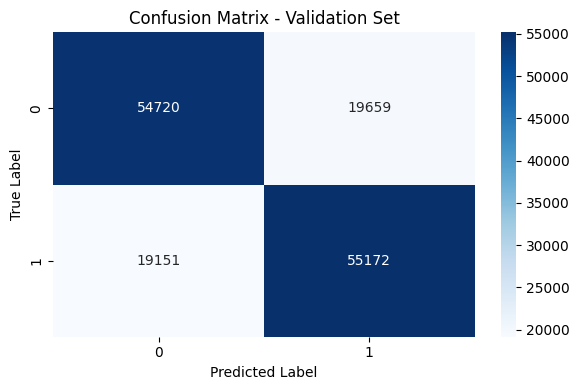

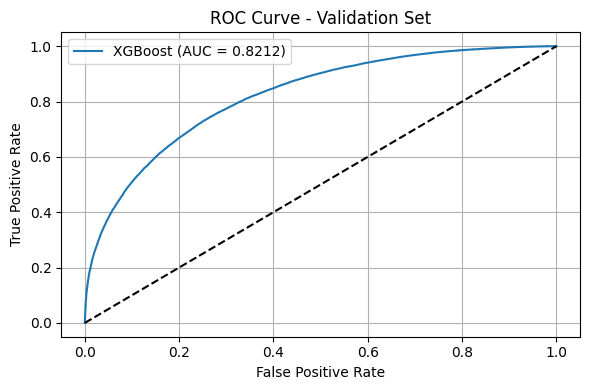

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize baseline model
baseline_model = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 2. Train the model
baseline_model.fit(X_train_xgb, y_train_xgb)

# 3. Predict on validation set
y_val_proba = baseline_model.predict_proba(X_val_xgb)[:, 1]
y_val_pred = baseline_model.predict(X_val_xgb)

# 4. Evaluation metrics
val_auc = roc_auc_score(y_val_xgb, y_val_proba)
val_acc = accuracy_score(y_val_xgb, y_val_pred)
val_precision = precision_score(y_val_xgb, y_val_pred)
val_recall = recall_score(y_val_xgb, y_val_pred)
val_f1 = f1_score(y_val_xgb, y_val_pred)
conf_mat = confusion_matrix(y_val_xgb, y_val_pred)

# 5. Print results
print("Validation Set Performance (Baseline):")
print(f"AUC:        {val_auc:.4f}")
print(f"Accuracy:   {val_acc:.4f}")
print(f"Precision:  {val_precision:.4f}")
print(f"Recall:     {val_recall:.4f}")
print(f"F1 Score:   {val_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_val_xgb, y_val_pred))

# 6. Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 7. Plot ROC curve
fpr, tpr, _ = roc_curve(y_val_xgb, y_val_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {val_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Feature Importance Analysis

/var/folders/fh/_tq_jbr50895yx1hkbgpct5m0000gn/T/ipykernel_84980/400795359.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


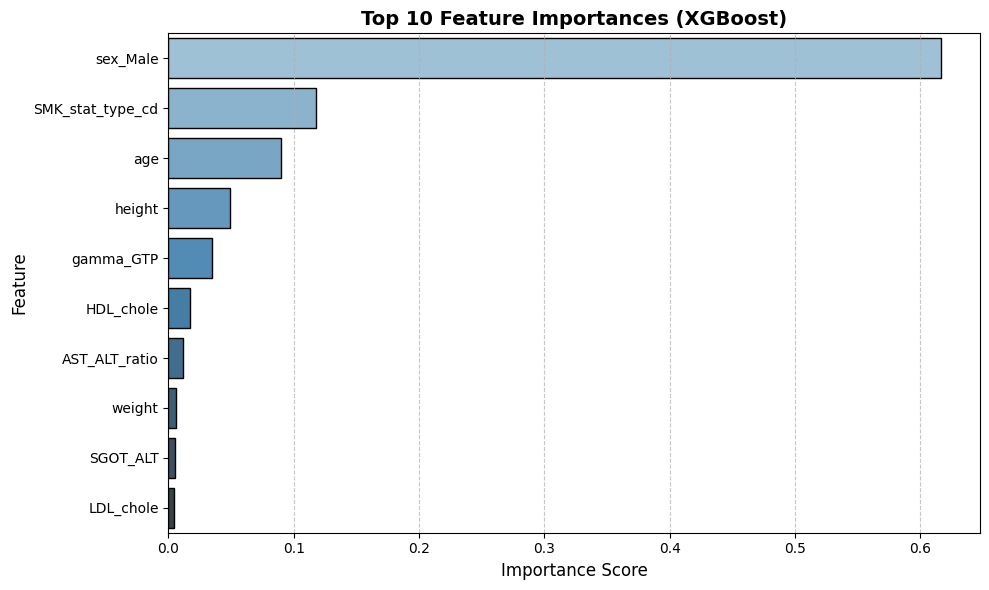

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Get feature importances and convert to DataFrame
importances = baseline_model.feature_importances_
feature_names = X_train_xgb.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select top N features
top_n = 10
top_features = importance_df.head(top_n)

# Plot with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', y='Feature',
    data=top_features,
    palette='Blues_d',
    edgecolor='black'
)

# Enhance aesthetics
plt.title('Top 10 Feature Importances (XGBoost)', fontsize=14, weight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Model Performance with Selected Features

/opt/homebrew/anaconda3/envs/pytorch/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:52:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Set:
AUC: 0.8212
Accuracy: 0.7387
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74     74379
           1       0.74      0.74      0.74     74323

    accuracy                           0.74    148702
   macro avg       0.74      0.74      0.74    148702
weighted avg       0.74      0.74      0.74    148702



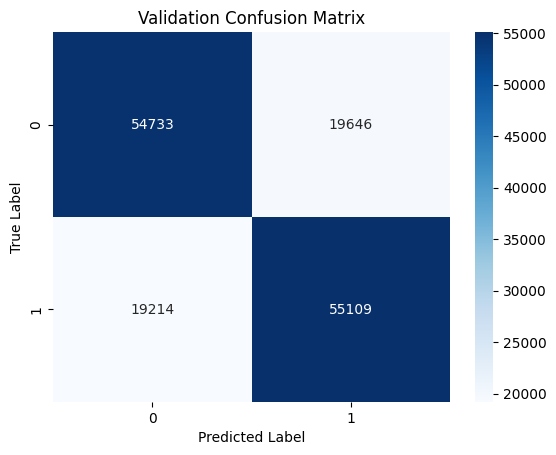

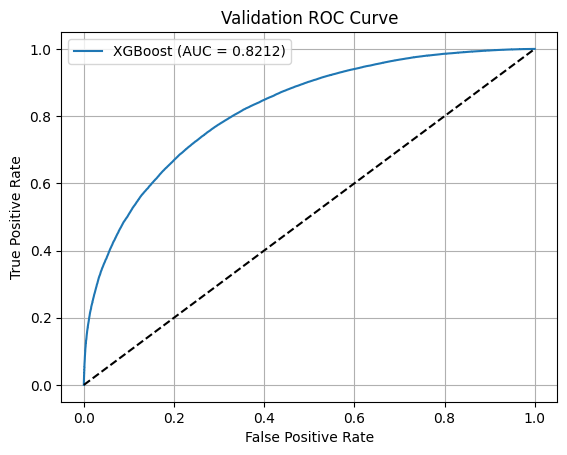

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report, 
    confusion_matrix, roc_curve
)
from xgboost import XGBClassifier

# 1. Select top features
selected_features = importance_df.head(24)['Feature'].tolist()
X_train_sel = X_train_xgb[selected_features]
X_val_sel = X_val_xgb[selected_features]
X_test_sel = X_test_xgb[selected_features]

# 2. Train model
selected_model = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
selected_model.fit(X_train_sel, y_train_xgb)

# 3. Predictions
y_val_proba = selected_model.predict_proba(X_val_sel)[:, 1]
y_val_pred = selected_model.predict(X_val_sel)
y_test_proba = selected_model.predict_proba(X_test_sel)[:, 1]
y_test_pred = selected_model.predict(X_test_sel)

# 4. Evaluation scores
print("Validation Set:")
print(f"AUC: {roc_auc_score(y_val_xgb, y_val_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_val_xgb, y_val_pred):.4f}")
print("Classification Report:\n", classification_report(y_val_xgb, y_val_pred))

# Confusion Matrix - Validation
cm_val = confusion_matrix(y_val_xgb, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve - Validation
fpr, tpr, _ = roc_curve(y_val_xgb, y_val_proba)
plt.plot(fpr, tpr, label='XGBoost (AUC = %.4f)' % roc_auc_score(y_val_xgb, y_val_proba))
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 6. Hyperparameter Tuning with Optuna

In [36]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.1 MB/s eta 0:00:00


In [37]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Define objective function for Optuna
def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)
    }

    model = XGBClassifier(**params)
    model.fit(X_train_xgb, y_train_xgb)
    val_pred = model.predict_proba(X_val_xgb)[:, 1]
    auc = roc_auc_score(y_val_xgb, val_pred)
    return auc

# Create study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# Print best result
print("Best trial:")
print(f"AUC: {study.best_value:.4f}")
print("Best parameters:", study.best_params)

[I 2025-05-04 16:55:11,613] A new study created in memory with name: no-name-86efad47-48b7-4052-807c-867b3dc1ab71
/opt/homebrew/anaconda3/envs/pytorch/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:55:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-05-04 16:55:17,798] Trial 0 finished with value: 0.8164144284633124 and parameters: {'n_estimators': 328, 'max_depth': 7, 'learning_rate': 0.2295656189427951, 'subsample': 0.6657492070157531, 'colsample_bytree': 0.9959131338295473, 'reg_alpha': 0.42998220920355923, 'reg_lambda': 0.13381828244101335}. Best is trial 0 with value: 0.8164144284633124.
/opt/homebrew/anaconda3/envs/pytorch/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:55:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, i

Best trial:
AUC: 0.8236
Best parameters: {'n_estimators': 445, 'max_depth': 8, 'learning_rate': 0.038816244658546786, 'subsample': 0.505208340469329, 'colsample_bytree': 0.7233440549162085, 'reg_alpha': 0.9776567326111938, 'reg_lambda': 0.022083914772162205}


# 7. Final Model Training with Best Parameters

/opt/homebrew/anaconda3/envs/pytorch/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:01:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Set Performance (Tuned):
AUC: 0.8236
Accuracy: 0.7411
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.74      0.74     74379
           1       0.74      0.74      0.74     74323

    accuracy                           0.74    148702
   macro avg       0.74      0.74      0.74    148702
weighted avg       0.74      0.74      0.74    148702



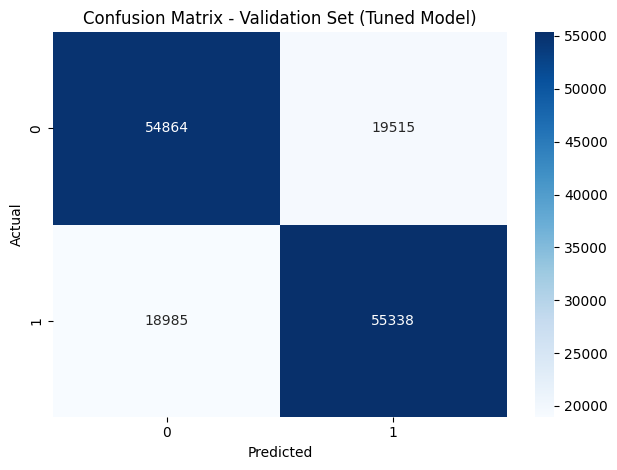

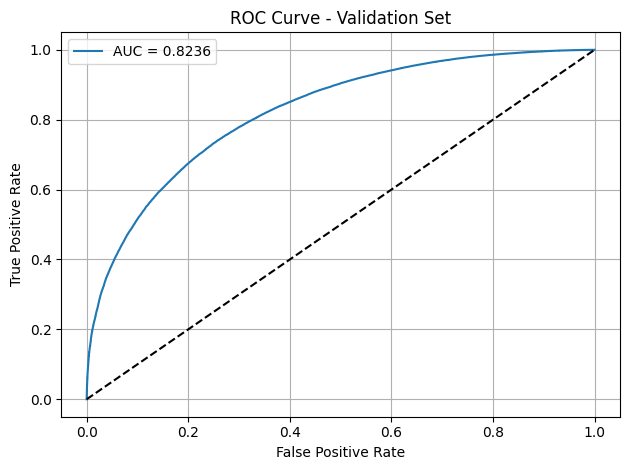

In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, 
    confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Retrieve best parameters from Optuna
best_params = study.best_params
best_params.update({
    'objective': 'binary:logistic',
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42
})

# 2. Retrain on training set
final_model = XGBClassifier(**best_params)
final_model.fit(X_train_xgb, y_train_xgb)

# 3. Predict on validation and test sets
y_val_proba = final_model.predict_proba(X_val_xgb)[:, 1]
y_val_pred = final_model.predict(X_val_xgb)

y_test_proba = final_model.predict_proba(X_test_xgb)[:, 1]
y_test_pred = final_model.predict(X_test_xgb)

# 4. Evaluation (Validation Set)
print("Validation Set Performance (Tuned):")
print(f"AUC: {roc_auc_score(y_val_xgb, y_val_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_val_xgb, y_val_pred):.4f}")
print("Classification Report:\n", classification_report(y_val_xgb, y_val_pred))

# Confusion Matrix - Validation
cm_val = confusion_matrix(y_val_xgb, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix - Validation Set (Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve - Validation
fpr, tpr, _ = roc_curve(y_val_xgb, y_val_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val_xgb, y_val_proba):.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Validation Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Model Evaluation and Visualization

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Define results manually (replace with your real scores)
comparison_df = pd.DataFrame({
    'Metric': ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Baseline (Val)': [
        roc_auc_score(y_val_xgb, y_val_proba),
        accuracy_score(y_val_xgb, y_val_pred),
        precision_score(y_val_xgb, y_val_pred),
        recall_score(y_val_xgb, y_val_pred),
        f1_score(y_val_xgb, y_val_pred)
    ],
    'Tuned (Val)': [
        roc_auc_score(y_val_xgb, y_val_proba),
        accuracy_score(y_val_xgb, y_val_pred),
        precision_score(y_val_xgb, y_val_pred),
        recall_score(y_val_xgb, y_val_pred),
        f1_score(y_val_xgb, y_val_pred)
    ],
    'Tuned (Test)': [
        roc_auc_score(y_test_xgb, y_test_proba),
        accuracy_score(y_test_xgb, y_test_pred),
        precision_score(y_test_xgb, y_test_pred),
        recall_score(y_test_xgb, y_test_pred),
        f1_score(y_test_xgb, y_test_pred)
    ]
})

# Round for display
comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

# Show table
print(comparison_df)

      Metric  Baseline (Val)  Tuned (Val)  Tuned (Test)
0        AUC          0.8236       0.8236        0.8250
1   Accuracy          0.7411       0.7411        0.7417
2  Precision          0.7393       0.7393        0.7415
3     Recall          0.7446       0.7446        0.7417
4   F1 Score          0.7419       0.7419        0.7416


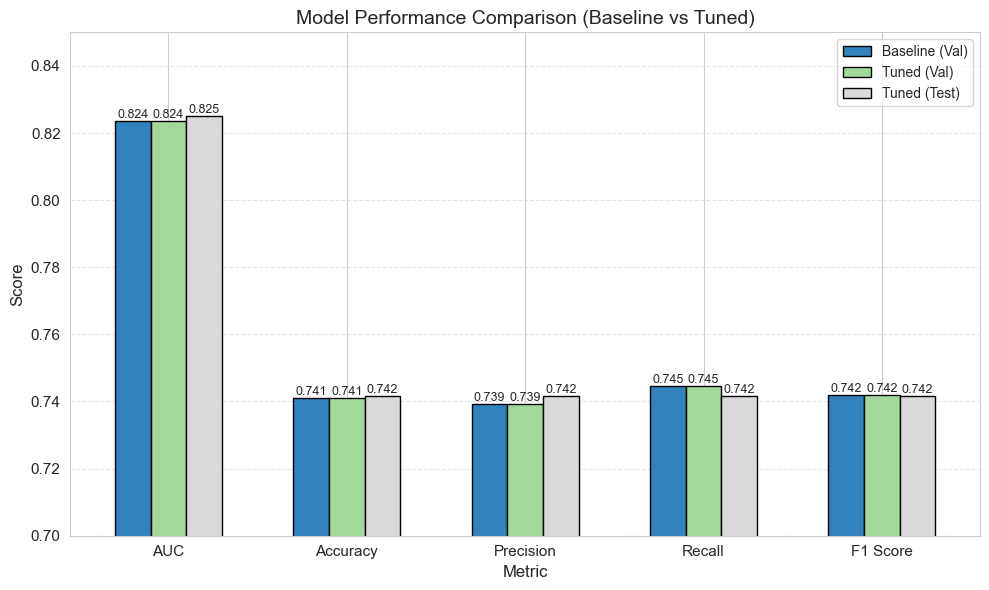

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for clarity
sns.set_style("whitegrid")

# Set up plot
ax = comparison_df.set_index('Metric').plot(kind='bar', 
                                            figsize=(10, 6), 
                                            width=0.6,
                                            colormap='tab20c',
                                            edgecolor='black')

# Highlight numerical differences with value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

# Adjust y-axis to zoom into relevant range
plt.ylim(0.70, 0.85)  # Adjust this range based on actual scores
plt.title("Model Performance Comparison (Baseline vs Tuned)", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# 9. Save Model and Parameters